Processing Ishihara Image...


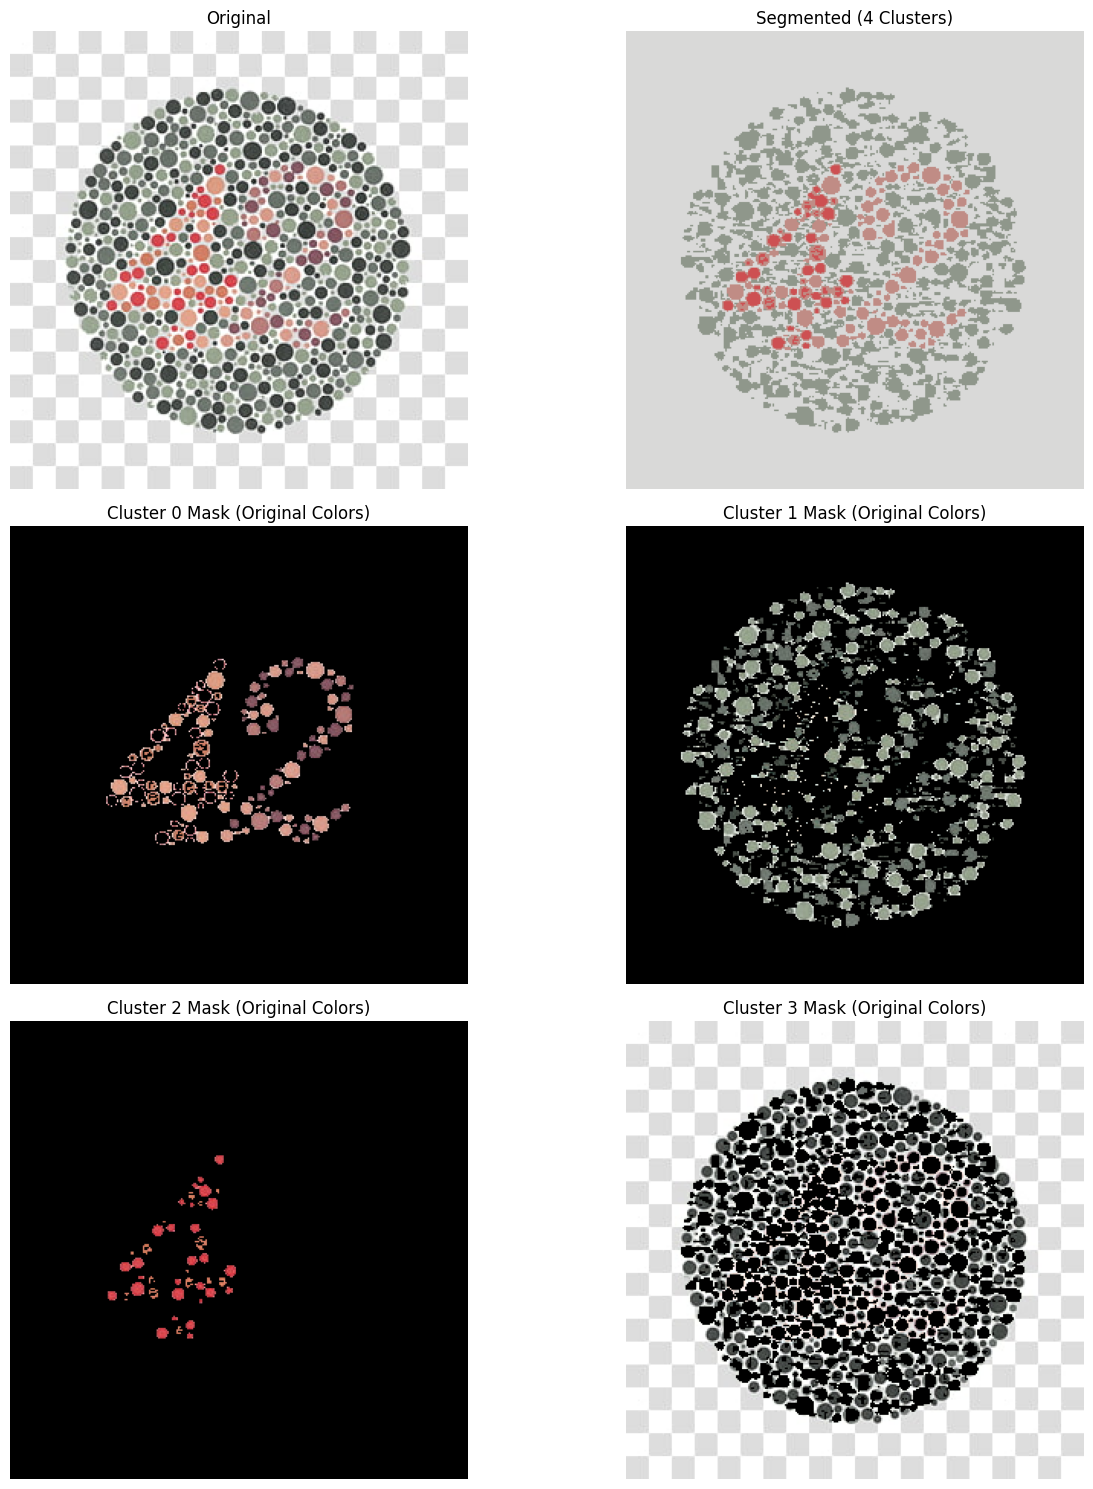

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, filters
import math

class CustomKMeans:
    def __init__(self, clusters=3, max_iterations=100, tolerance=1e-4):
        self.k = clusters
        self.max_iter = max_iterations
        self.tol = tolerance
        self.centroids = None
        self.assignments = None

    def _choose_initial_centroids(self, data):
        return data[np.random.choice(len(data), self.k, replace=False)]

    def _compute_distances(self, data):
        return np.linalg.norm(data[:, None] - self.centroids, axis=2)

    def _compute_new_centroids(self, data, labels):
        updated = []
        for cluster_idx in range(self.k):
            cluster_points = data[labels == cluster_idx]
            if cluster_points.size > 0:
                updated.append(np.mean(cluster_points, axis=0))
            else:
                updated.append(data[np.random.randint(len(data))])
        return np.array(updated)

    def fit(self, data):
        self.centroids = self._choose_initial_centroids(data)
        for _ in range(self.max_iter):
            distances = self._compute_distances(data)
            labels = np.argmin(distances, axis=1)
            new_centroids = self._compute_new_centroids(data, labels)
            if np.allclose(self.centroids, new_centroids, atol=self.tol):
                break
            self.centroids = new_centroids
        self.assignments = labels

class IshiharaProcessor:
    def __init__(self, k=6):
        self.k = k

    def segment_image(self, img):
        lab = color.rgb2lab(img)
        ab_channels = lab[:, :, 1:3].reshape(-1, 2)

        clustering = CustomKMeans(clusters=self.k)
        clustering.fit(ab_channels)
        labels = clustering.assignments.reshape(img.shape[:2])

        segmented = np.zeros_like(img)
        for i in range(self.k):
            mask = labels == i
            if np.any(mask):
                segmented[mask] = np.mean(img[mask], axis=0)

        return labels, segmented

    def create_binary_masks(self, labels):
        binaries = []
        for i in range(self.k):
            mask = (labels == i).astype(np.uint8)
            thresh = filters.threshold_otsu(mask)
            binaries.append(mask > thresh)
        return binaries

    def display_results(self, original, segmented, binaries):
        total = 2 + len(binaries)
        rows = math.ceil(total / 2)
        cols = 2

        plt.figure(figsize=(14, 5 * rows))
        plt.subplot(rows, cols, 1)
        plt.imshow(original)
        plt.title("Original")
        plt.axis("off")

        plt.subplot(rows, cols, 2)
        plt.imshow(segmented)
        plt.title(f"Segmented ({self.k} Clusters)")
        plt.axis("off")

        for idx, binary in enumerate(binaries):
            plt.subplot(rows, cols, 3 + idx)

            color_mask = np.zeros_like(original)
            color_mask[binary] = original[binary]

            plt.imshow(color_mask)
            plt.title(f"Cluster {idx} Mask (Original Colors)")
            plt.axis("off")



        plt.tight_layout()
        plt.show()

    def process(self, image_path):
        img = io.imread(image_path)
        labels, segmented = self.segment_image(img)
        binary_masks = self.create_binary_masks(labels)
        self.display_results(img, segmented, binary_masks)

if __name__ == "__main__":
    image_path = "/content/42.jpg"
    print("Processing Ishihara Image...")
    processor = IshiharaProcessor(k=4)
    processor.process(image_path)